# 05 — Modeling: Comparing Classifiers

Trains and compares three classifiers on `outputs/processed/combined_features.csv` (frequency-domain + statistical/temporal features, 1313 windows x 20 subjects), to predict which of the four phases (Relax, PhysicalStress, CognitiveStress, EmotionalStress) a window belongs to.

## Design decisions

| Decision | Choice | Why |
|---|---|---|
| Models compared | Logistic Regression, Random Forest, Gradient Boosting (`HistGradientBoostingClassifier`) | A linear baseline plus two tree ensembles (bagged, boosted) -- enough spread to see whether threshold/nonlinear splits actually beat a linear combination of the hand-engineered features. k-Nearest Neighbors and SVM (RBF) were tried and dropped: k-NN has no `class_weight` support against the Relax-heavy imbalance and its distance metric degrades with 36 correlated features; SVM (RBF)'s accuracy is too sensitive to `C`/`gamma` to judge fairly at defaults, and not worth tuning a model being cut anyway. |
| Evaluation protocol | 5-fold `StratifiedGroupKFold`, grouped by `subject_id` | A subject's windows must never appear in both train and test within a fold -- required given the overlapping 60s/30s windows (they share raw samples) and per-subject physiological baseline differences. Stratified so each fold keeps a similar class balance as far as the grouping constraint allows. |
| Primary metric | Macro-averaged F1 | Relax is ~54% of the data; plain accuracy would reward a model that just predicts Relax. Macro-F1 weighs all four classes equally. |
| Class imbalance handling | `class_weight='balanced'` for all three models | Counteracts the same Relax-heavy imbalance at training time, not just at evaluation time. |
| Feature scaling | `StandardScaler` in every model's pipeline | Required for Logistic Regression; harmless (a no-op on split quality) for the tree ensembles, so applying it uniformly keeps the code simple. |
| Hyperparameter tuning | Grid search per model (`src/modeling.py::PARAM_GRIDS`), scored on the same grouped 5-fold split used for evaluation | A single tuning pass over the whole dataset, not fully nested per outer fold -- reported tuned scores are "best CV score found," not an estimate fully independent of the search that chose it. |

Every window gets exactly one out-of-fold (OOF) prediction, made by a fold that never saw that window's subject during training. All reported metrics are computed on these OOF predictions -- equivalent to 5-fold cross-validation, reported as one clean evaluation per model rather than five separate ones.

Model pipelines, the CV routine, and the tuning grids live in `src/modeling.py`, shared with `thesis_overview.ipynb`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.modeling import PARAM_GRIDS, RANDOM_STATE, build_models, run_cv, tune_models

CLASS_ORDER = ['Relax', 'PhysicalStress', 'CognitiveStress', 'EmotionalStress']

## Load features

In [2]:
features_df = pd.read_csv('../outputs/processed/combined_features.csv')

METADATA_COLUMNS = ['window_index', 'label', 'start_time', 'subject_id']
LOW_IMPORTANCE_COLUMNS = [
    'acc_total_power', 'eda_total_power', 'spo2_dominant_frequency', 'acc_postural_power',
    'eda_skewness', 'hr_lf_power', 'hr_dominant_frequency', 'eda_dominant_frequency', 'temp_dominant_frequency',
]  # <=0 permutation importance -- shuffling them doesn't hurt (or slightly helps) the model
FEATURE_COLUMNS = [c for c in features_df.columns if c not in METADATA_COLUMNS + LOW_IMPORTANCE_COLUMNS]

X = features_df[FEATURE_COLUMNS]
y = features_df['label']
groups = features_df['subject_id']

print(f"Rows: {len(X)}, Features: {len(FEATURE_COLUMNS)}, Subjects: {groups.nunique()}")
print(f"NaN: {X.isna().sum().sum()}, Inf: {np.isinf(X.to_numpy()).sum()}")
print()
print(y.value_counts().reindex(CLASS_ORDER))

Rows: 1313, Features: 36, Subjects: 20
NaN: 0, Inf: 0

label
Relax              709
PhysicalStress     180
CognitiveStress    201
EmotionalStress    223
Name: count, dtype: int64


## Models

In [3]:
MODELS = build_models()

## Cross-validate every model

In [4]:
baseline_results = run_cv(X, y, groups, MODELS)

for model_name, r in baseline_results.items():
    print(f"{model_name:22s} fold macro-F1 = {r['fold_macro_f1_mean']:.3f} +/- {r['fold_macro_f1_std']:.3f}   "
          f"OOF macro-F1 = {r['oof_macro_f1']:.3f}   OOF accuracy = {r['oof_accuracy']:.3f}")

Logistic Regression    fold macro-F1 = 0.728 +/- 0.071   OOF macro-F1 = 0.729   OOF accuracy = 0.731
Random Forest          fold macro-F1 = 0.757 +/- 0.076   OOF macro-F1 = 0.766   OOF accuracy = 0.786
Gradient Boosting      fold macro-F1 = 0.747 +/- 0.070   OOF macro-F1 = 0.757   OOF accuracy = 0.786


## Hyperparameter tuning

The run above uses each model's library defaults. `tune_models` (`src/modeling.py`) grid-searches each model's key hyperparameters (`PARAM_GRIDS`), scored on the identical grouped `StratifiedGroupKFold` split used for evaluation, so the search itself can't leak a subject's windows across its own train/validation boundary. From here on `MODELS`/`results` refer to the **tuned** models -- everything below (comparison table, confusion matrices, feature importance, confound ablation) runs on these, not the baseline defaults.

In [5]:
tuned = tune_models(X, y, groups, MODELS, PARAM_GRIDS)

print("Best hyperparameters found (grouped 5-fold grid search):")
for name, info in tuned.items():
    print(f"  {name}: {info['best_params']}")

MODELS = {name: info['pipeline'] for name, info in tuned.items()}
results = run_cv(X, y, groups, MODELS)

print("\nBaseline (defaults) vs. tuned OOF macro-F1:")
for model_name, r in results.items():
    baseline_f1 = baseline_results[model_name]['oof_macro_f1']
    print(f"  {model_name:22s} baseline={baseline_f1:.3f}  tuned={r['oof_macro_f1']:.3f}  delta={r['oof_macro_f1'] - baseline_f1:+.3f}")

Best hyperparameters found (grouped 5-fold grid search):
  Logistic Regression: {'clf__C': 0.1}
  Random Forest: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
  Gradient Boosting: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__max_iter': 100}



Baseline (defaults) vs. tuned OOF macro-F1:
  Logistic Regression    baseline=0.729  tuned=0.736  delta=+0.007
  Random Forest          baseline=0.766  tuned=0.772  delta=+0.006
  Gradient Boosting      baseline=0.757  tuned=0.761  delta=+0.004


## Comparison table

In [6]:
summary_df = pd.DataFrame([
    {
        'model': name,
        'fold_macro_f1_mean': r['fold_macro_f1_mean'],
        'fold_macro_f1_std': r['fold_macro_f1_std'],
        'oof_macro_f1': r['oof_macro_f1'],
        'oof_accuracy': r['oof_accuracy'],
    }
    for name, r in results.items()
]).sort_values('oof_macro_f1', ascending=False).reset_index(drop=True)

summary_df

,model,fold_macro_f1_mean,fold_macro_f1_std,oof_macro_f1,oof_accuracy
0,Random Forest,0.762979,0.072909,0.771992,0.791318
1,Gradient Boosting,0.749991,0.055374,0.760788,0.782940
2,Logistic Regression,0.734837,0.074153,0.736376,0.734958


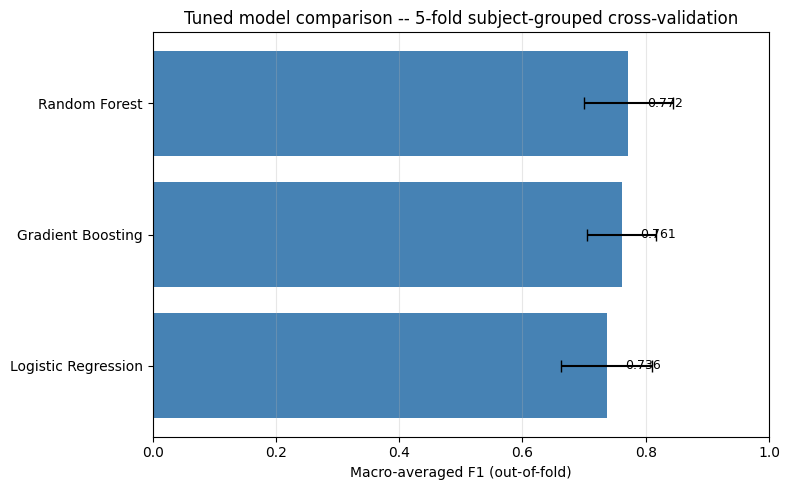

In [7]:
plot_df = summary_df.sort_values('oof_macro_f1')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(plot_df['model'], plot_df['oof_macro_f1'], xerr=plot_df['fold_macro_f1_std'],
                color='steelblue', capsize=4)
ax.set_xlabel('Macro-averaged F1 (out-of-fold)')
ax.set_xlim(0, 1)
ax.set_title('Tuned model comparison -- 5-fold subject-grouped cross-validation')
ax.grid(axis='x', alpha=0.3)

for bar, value in zip(bars, plot_df['oof_macro_f1']):
    ax.text(min(value + 0.03, 0.97), bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Per-class detail -- best model

In [8]:
best_model_name = summary_df.iloc[0]['model']
print(f"Best model: {best_model_name}\n")
print(classification_report(y, results[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))

Best model: Random Forest

                 precision    recall  f1-score   support

          Relax      0.849     0.835     0.842       709
 PhysicalStress      0.961     0.961     0.961       180
CognitiveStress      0.736     0.761     0.748       201
EmotionalStress      0.531     0.543     0.537       223

       accuracy                          0.791      1313
      macro avg      0.769     0.775     0.772      1313
   weighted avg      0.793     0.791     0.792      1313



## Confusion matrices -- all models

Row-normalized (each row sums to 100%): shows, for windows truly belonging to a given phase, what percentage the model predicted for each phase.

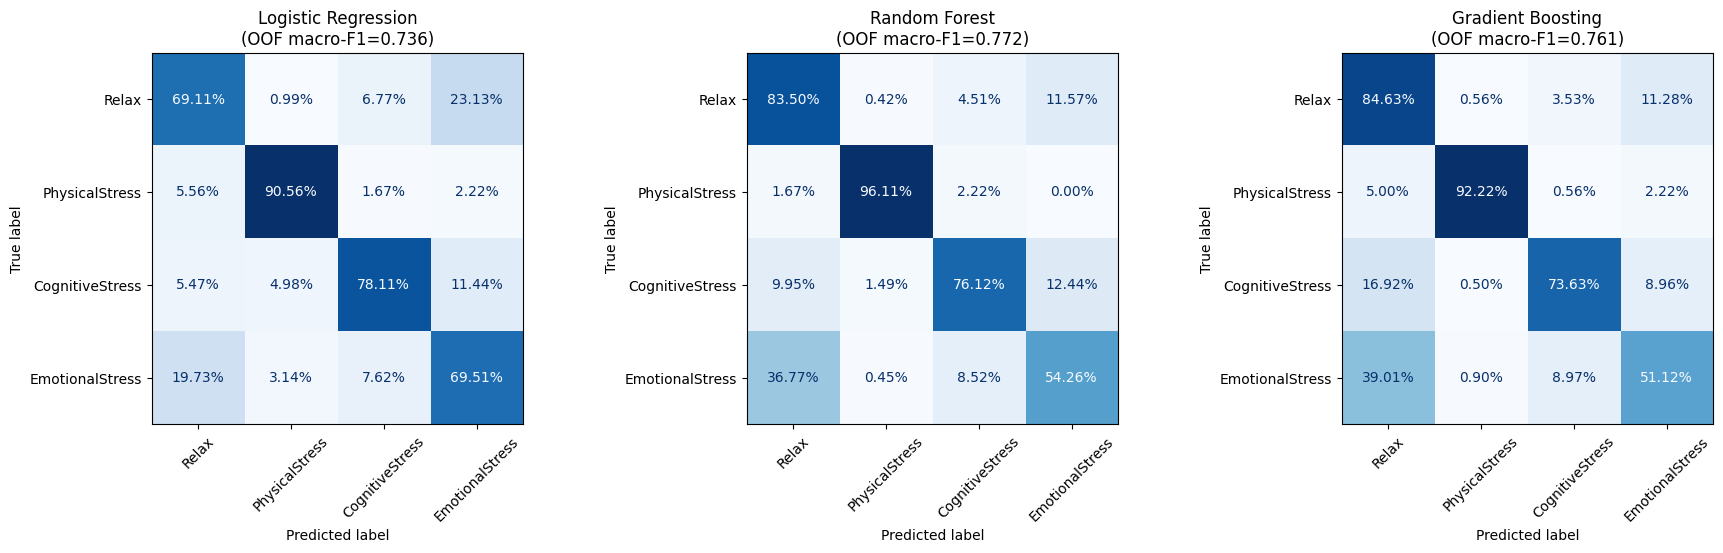

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
axes = axes.ravel()

for ax, (model_name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y, r['oof_predictions'], labels=CLASS_ORDER, normalize='true', cmap='Blues',
        ax=ax, colorbar=False, xticks_rotation=45, values_format='.2%',
    )
    ax.set_title(f"{model_name}\n(OOF macro-F1={r['oof_macro_f1']:.3f})")

for ax in axes[len(results):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Feature importance

Random Forest, refit on the full dataset -- this fit is for interpretability only, not a performance claim (those come from the cross-validation above). Answers the question flagged early in `thesis_notes.md`'s Classification Decisions: are temperature and SpO2 actually low-importance, as the time-domain analysis in notebook 01/02 expected?

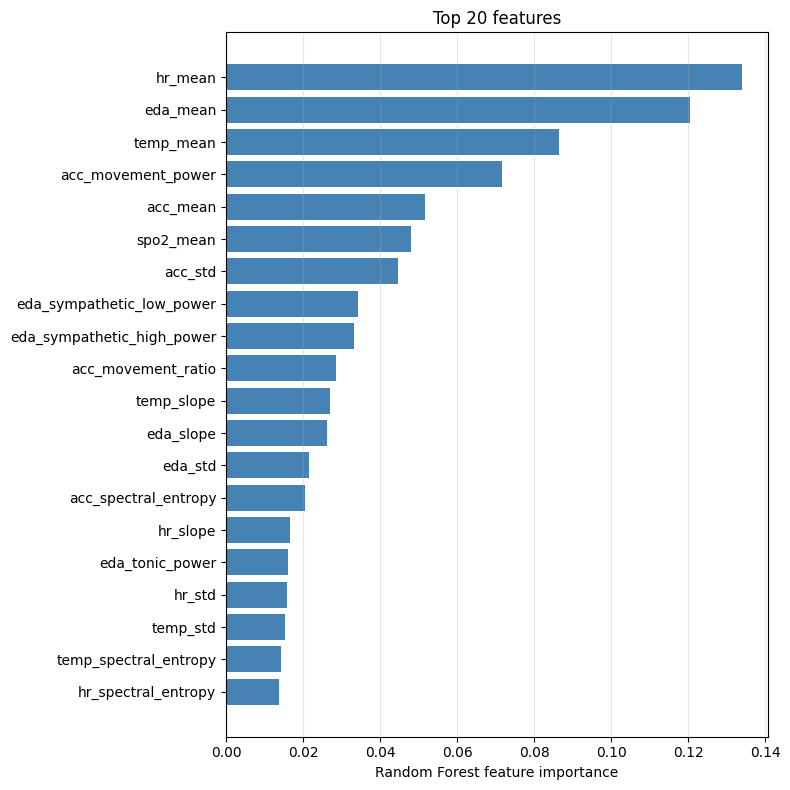

In [10]:
importance_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)),
])
importance_pipeline.fit(X, y)

importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': importance_pipeline.named_steps['clf'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
importance_df['rank'] = importance_df.index + 1

top_n = 20
plot_df = importance_df.head(top_n).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(plot_df['feature'], plot_df['importance'], color='steelblue')
ax.set_xlabel('Random Forest feature importance')
ax.set_title(f'Top {top_n} features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
temp_spo2 = importance_df[importance_df['feature'].str.startswith(('temp_', 'spo2_'))]
print(f"temp_/spo2_ features occupy ranks {temp_spo2['rank'].min()}-{temp_spo2['rank'].max()} of {len(importance_df)}, "
      f"summing to {temp_spo2['importance'].sum() * 100:.1f}% of total importance "
      f"({len(temp_spo2)} features out of {len(importance_df)} total).")

temp_/spo2_ features occupy ranks 3-36 of 36, summing to 25.6% of total importance (12 features out of 36 total).


## Confound check -- is `temp_mean`'s importance real?

`temp_mean` ranked #3 in the feature-importance plot above, which is surprising: the signal notes in notebooks 01/02 expected Temp and SpO2 to rank low, on the grounds that skin temperature responds too slowly to be a stress marker and mostly just drifts upward for the whole session. Worth checking directly rather than taking the ranking at face value -- especially since Random Forest's built-in `feature_importances_` (impurity-based) is known to be biased toward continuous features, which is exactly what `temp_mean` is. `sklearn.inspection.permutation_importance` (shuffle a feature, measure how much the score degrades) is a more trustworthy alternative.

In [12]:
permutation_result = permutation_importance(
    importance_pipeline, X, y, n_repeats=15, random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1
)
permutation_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'permutation_importance': permutation_result.importances_mean,
}).sort_values('permutation_importance', ascending=False).reset_index(drop=True)
permutation_df['rank'] = permutation_df.index + 1

top_4_share = permutation_df.head(4)['permutation_importance'].sum() / permutation_df['permutation_importance'].sum()
print(f"Top 4 features carry {top_4_share * 100:.0f}% of total permutation importance:\n")
print(permutation_df[['rank', 'feature', 'permutation_importance']].head(10).to_string(index=False))

Top 4 features carry 72% of total permutation importance:

 rank               feature  permutation_importance
    1               hr_mean                0.071532
    2              eda_mean                0.070627
    3             temp_mean                0.036810
    4             spo2_mean                0.007370
    5             eda_slope                0.004503
    6   hr_spectral_entropy                0.004240
    7 temp_spectral_entropy                0.004045
    8              temp_std                0.003799
    9           hr_skewness                0.003521
   10    acc_movement_power                0.003342


In [13]:
temp_window_corr = features_df['temp_mean'].corr(features_df['window_index'])
print(f"temp_mean vs window_index correlation: {temp_window_corr:.3f}")

temp_mean vs window_index correlation: 0.755


A correlation this strong (0.75) isn't a coincidence: every subject goes through the four phases in the same fixed order (Relax -> PhysicalStress -> Relax -> CognitiveStress -> Relax -> EmotionalStress -> Relax), and Temp drifts monotonically upward across the whole session regardless of which phase is active (see notebook 01/02 signal notes). `window_index` is literally "how far into the subject's window sequence is this row" -- so `temp_mean` is acting as a proxy for elapsed session time, not a genuine response to a specific stress type. A model trained on it could partly be learning "how far into this fixed protocol are we" rather than "what phase is this" -- a pattern that wouldn't hold up on a subject who did the phases in a different order or for a different session length.

Re-running the model comparison with all `temp_*`/`spo2_*` features excluded checks how much of the reported score depends on this.

In [14]:
no_confound_columns = [c for c in FEATURE_COLUMNS if not (c.startswith('temp_') or c.startswith('spo2_'))]
X_no_confound = features_df[no_confound_columns]

results_no_confound = run_cv(X_no_confound, y, groups, MODELS)

print(f"{'Model':22s} {'macro-F1 (36 feat)':>20s} {'macro-F1 (24 feat)':>20s} {'Delta':>8s}")
print('-' * 74)
for model_name in MODELS:
    baseline = results[model_name]['oof_macro_f1']
    no_confound = results_no_confound[model_name]['oof_macro_f1']
    print(f"{model_name:22s} {baseline:>20.3f} {no_confound:>20.3f} {no_confound - baseline:>8.3f}")

Model                    macro-F1 (36 feat)   macro-F1 (24 feat)    Delta
--------------------------------------------------------------------------
Logistic Regression                   0.736                0.704   -0.032
Random Forest                         0.772                0.744   -0.028
Gradient Boosting                     0.761                0.731   -0.029


### Per-class detail: does the confound-free model hold up class-by-class?

In [15]:
print(f"Best model: {best_model_name}\n")
print("-- All 36 features --")
print(classification_report(y, results[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))
print("-- temp_*/spo2_* excluded (24 features) --")
print(classification_report(y, results_no_confound[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))

Best model: Random Forest

-- All 36 features --
                 precision    recall  f1-score   support

          Relax      0.849     0.835     0.842       709
 PhysicalStress      0.961     0.961     0.961       180
CognitiveStress      0.736     0.761     0.748       201
EmotionalStress      0.531     0.543     0.537       223

       accuracy                          0.791      1313
      macro avg      0.769     0.775     0.772      1313
   weighted avg      0.793     0.791     0.792      1313

-- temp_*/spo2_* excluded (24 features) --
                 precision    recall  f1-score   support

          Relax      0.839     0.794     0.816       709
 PhysicalStress      0.913     0.933     0.923       180
CognitiveStress      0.722     0.736     0.729       201
EmotionalStress      0.478     0.543     0.508       223

       accuracy                          0.762      1313
      macro avg      0.738     0.752     0.744      1313
   weighted avg      0.770     0.762     0.765  

The first-pass hypothesis from notebooks 01/02 -- that Temp and SpO2 wouldn't be useful discriminators -- turns out to be **empirically wrong**: dropping them costs real score for every remaining model, suggesting these two signals were adding real predictive value, not just noise.

The per-class breakdown for Random Forest shows where that value concentrates: PhysicalStress and EmotionalStress lose the most, while Relax and CognitiveStress barely move. PhysicalStress losing the most is worth a second look on its own terms -- transient SpO2 dips and skin-temperature changes during real physical exertion are physiologically plausible, which isn't actually in conflict with Temp/SpO2 being flat during *resting* mental-stress phases (the case the original signal notes were describing). Distinguishing "genuine exertion-related SpO2 signal" from "temp's session-position confound riding along in the same drop" would need testing each signal in isolation -- not done here, left as an open follow-up.

**Takeaway:** report the Random Forest, `temp_*`/`spo2_*`-excluded macro-F1 from the table above as the trustworthy estimate of real-world performance -- it doesn't depend on a shortcut that's an artifact of this protocol's fixed phase ordering. The all-features headline number reported earlier is real but partly inflated by that shortcut, and shouldn't be quoted without this caveat.

## Summary

In [16]:
print(f"Best model: {best_model_name}")
print(f"  OOF macro-F1 = {results[best_model_name]['oof_macro_f1']:.3f}  (all 36 features)")
print(f"  OOF macro-F1 = {results_no_confound[best_model_name]['oof_macro_f1']:.3f}  (temp_*/spo2_* excluded -- more trustworthy, see confound check above)")
print(f"  OOF accuracy = {results[best_model_name]['oof_accuracy']:.3f}")
print()
print("Top 5 most important features (Random Forest, permutation importance):")
print(permutation_df[['rank', 'feature', 'permutation_importance']].head(5).to_string(index=False))

Best model: Random Forest
  OOF macro-F1 = 0.772  (all 36 features)
  OOF macro-F1 = 0.744  (temp_*/spo2_* excluded -- more trustworthy, see confound check above)
  OOF accuracy = 0.791

Top 5 most important features (Random Forest, permutation importance):
 rank   feature  permutation_importance
    1   hr_mean                0.071532
    2  eda_mean                0.070627
    3 temp_mean                0.036810
    4 spo2_mean                0.007370
    5 eda_slope                0.004503


## Limitations

- Hyperparameter tuning is a single grouped-CV grid search over the whole dataset (`src/modeling.py::tune_models`), not fully nested per outer fold -- reported tuned scores are "best CV score found on this data," not a fully independent held-out estimate. With only 20 subjects, true nested CV would leave too little data per inner search to tune reliably.
- Only 20 subjects: `StratifiedGroupKFold` folds hold out 4 subjects at a time, so per-fold scores can be noisy; the fold mean/std reported above is a better estimate of variability than any single fold.
- The all-features headline macro-F1 is partly inflated by a session-position confound in `temp_mean` (correlates 0.75 with `window_index`, an artifact of every subject following the same fixed phase order -- see "Confound check" above); the `temp_*`/`spo2_*`-excluded score is the more defensible estimate of real-world performance.